Retrieving InsertionElectrodeDoc documents: 100%|██████████| 2168/2168 [00:00<00:00, 6113.26it/s]


average_voltage: 3.8337958846090303
energy_grav: 510.6408612123828
energy_vol: 1746.2057268762278
capacity_grav: 135.10599373918325
capacity_vol: 465.51157361668743
max_delta_volume: 0.04623113157087715
stability_charge: 0.06437952461418037
stability_discharge: 0.04478372404622442
fracA_charge: 0.04620769303713471
fracA_discharge: 0.15723280751197727
2168


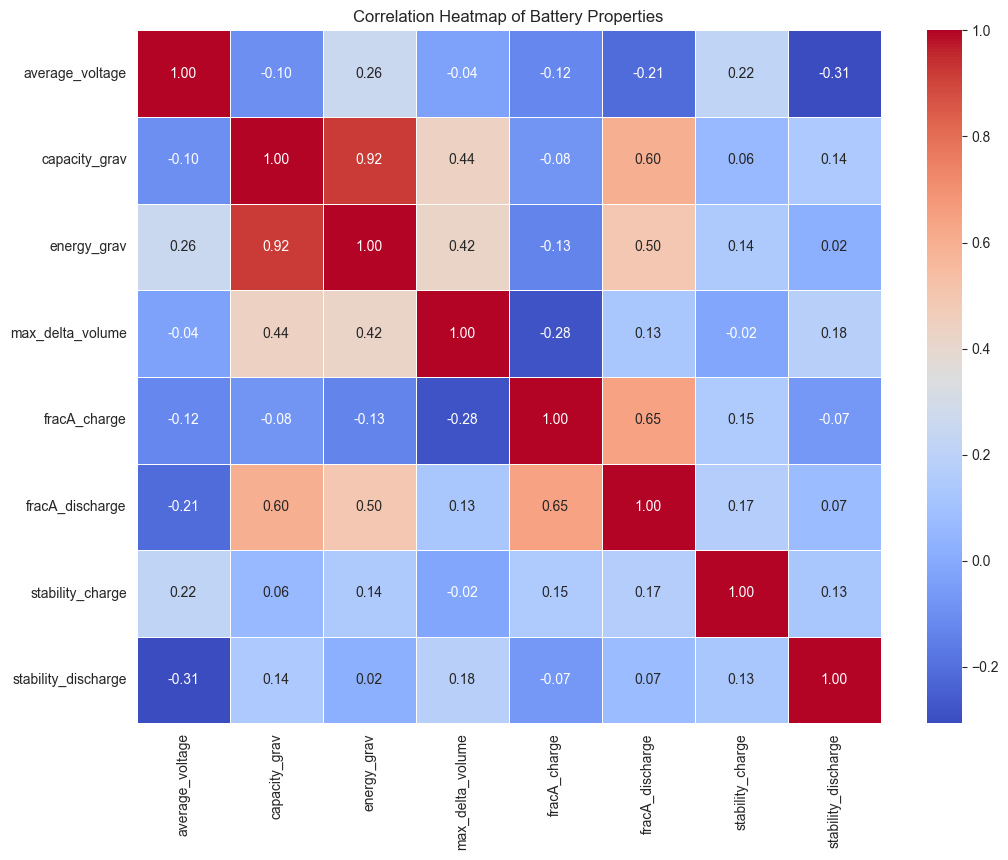


Data Size: 2168


In [4]:
# LITHIUM

from mp_api.client import MPRester
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
API_KEY = "4IeHY5jVcrgiKXNuAo6Jgs7yC0Z3hsli"
try:
    with MPRester(API_KEY) as mpr:
        # Query for Li-based cathode materials with high energy density
        docs = mpr.materials.insertion_electrodes.search(
        working_ion="Li",
        average_voltage = (2.5, 8.0), stability_charge=(0.0, 0.2),
        fields=[
            "battery_id", "formula_discharge", "average_voltage"
            , "energy_grav", "energy_vol", "capacity_grav", "capacity_vol", "stability_charge", "fracA_charge", "max_delta_volume", "stability_discharge", "fracA_discharge"
        ])

        Fields = "average_voltage", "energy_grav", "energy_vol", "capacity_grav", "capacity_vol", "max_delta_volume", "stability_charge", "stability_discharge", "fracA_charge", "fracA_discharge"

        def average_field(docs, field):
            vals = [getattr(d, field) for d in docs if getattr(d, field) is not None]
            return sum(vals) / len(vals)


        df = pd.DataFrame([doc.dict() for doc in docs])
        df.head(20)

        for f in Fields:
            avg = average_field(docs, f)
            print(f"{f}: {avg}")
        print(len(df))
        df.head(20)

         # Select only the numeric columns relevant to battery performance
    cols_to_analyze = ['average_voltage', 'capacity_grav', 'energy_grav',
                        'max_delta_volume',
                       'fracA_charge', 'fracA_discharge', 'stability_charge', 'stability_discharge']
    correlation_matrix = (df[cols_to_analyze].corr(method="spearman"))
    correlation_matrix.head()
    plt.figure(figsize=(12, 9))
    sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
    plt.title("Correlation Heatmap of Battery Properties")
    plt.show()
    print(f"\nData Size: {len(df)}")



except Exception as e:
    print(f"An error occurred: {e}")




In [16]:
voltages = [doc.average_voltage for doc in docs if doc.average_voltage is not None]
instabilities = [doc.stability_discharge for doc in docs if doc.stability_charge is not None]

mp-755193_Li: 6.230379483333334V
mp-26997_Li: 6.078896553333341V
mp-25977_Li: 6.042174743333309V
mp-26001_Li: 5.831597953333334V
mp-504354_Li: 5.646601353333328V
mp-26015_Li: 5.529354370833322V
mp-1111927_Li: 5.506705943333333V
mp-18878_Li: 5.443386683333334V
mp-17664_Li: 5.268361598333333V
mp-1111150_Li: 5.18577194333334V
mp-758760_Li: 5.147194610833329V
mp-25991_Li: 5.060933100833329V
mp-25261_Li: 5.054418733333333V
mp-562404_Li: 5.04306379083332V
mp-22243_Li: 5.032981518333333V
mp-21650_Li: 5.022759379583332V
mp-26952_Li: 4.992434318333342V
mp-26019_Li: 4.965640293333328V
mp-3731_Li: 4.955458718333296V
mp-22417_Li: 4.954485295833335V
mp-18932_Li: 4.947659528333336V
mp-26975_Li: 4.926321129999986V
mp-26035_Li: 4.897374787499998V
mp-752929_Li: 4.887855148333334V
mp-19103_Li: 4.855683173333323V
mp-560878_Li: 4.8494436633333375V
mp-26955_Li: 4.835385495833326V
mp-675534_Li: 4.81353371083333V
mp-753573_Li: 4.793945038333338V
mp-674219_Li: 4.722374733333344V
mp-771112_Li: 4.71485651958333

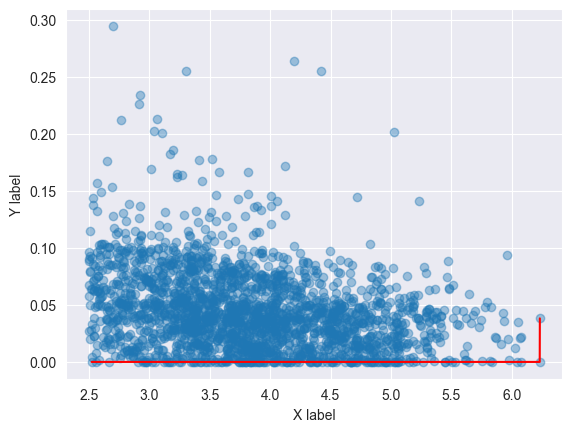

In [17]:
import matplotlib.pyplot as plt

def plot_pareto_frontier(Xs, Ys, maxX=True, maxY=False, xlabel='X label', ylabel='Y label'):
    '''Pareto frontier selection process
    :param Xs: Series of X values
    :param Ys: Series of Y values
    :param maxX: True if maximizing on X
    :param maxY: True if maximizing on Y
    :param xlabel: plot label for X
    :parma ylabel: plot label for Y
    '''
    n = 0
    sorted_list = sorted([[Xs[i], Ys[i]] for i in range(len(Xs))], reverse=maxX) # Sorts values (descending if reverse = True)
    pareto_front = [sorted_list[0]]
    battery_ids = []
    for pair in sorted_list[1:]:
        if maxY:
            if pair[1] >= pareto_front[-1][1]:
                pareto_front.append(pair)
                for id in docs:
                    if id.average_voltage == pair[0] or id.stability_discharge == pair[0]:
                        print(f"{id.battery_id}: {pair[0]}V") # Print ID and voltage

        else:
            if pair[1] <= pareto_front[-1][1]:
                pareto_front.append(pair)
                for id in docs:
                    if id.average_voltage == pair[0] or id.stability_discharge == pair[0]:
                        print(f"{id.battery_id}: {pair[0]}V") # Print ID and voltage


    '''Plotting process'''
    plt.scatter(Xs,Ys, alpha=0.4)
    pf_X = [pair[0] for pair in pareto_front]
    pf_Y = [pair[1] for pair in pareto_front]
    plt.plot(pf_X, pf_Y, color='red')
    plt.xlabel(xlabel)
    plt.ylabel(ylabel)
    plt.show()

    #return pareto_front

plot_pareto_frontier(voltages, instabilities)


In [13]:
capacity = [doc.capacity_grav for doc in docs if doc.capa is not None]
instabilities = [doc.stability_discharge for doc in docs if doc.stability_charge is not None]

mp-19308_Li: 512.583049076424V
mp-35925_Li: 512.583049076424V
mp-25323_Li: 430.787772220729V
mp-18925_Li: 325.7018238247244V
mp-19340_Li: 298.1875111437406V
mp-18793_Li: 294.72937690575327V
mp-756362_Li: 294.72937690575327V
mp-21633_Li: 288.5681979329664V
mp-753390_Li: 288.5681979329664V
mp-753571_Li: 288.5681979329664V
mp-753667_Li: 288.5681979329664V
mp-759464_Li: 288.5681979329664V
mp-777681_Li: 288.5681979329664V
mp-18767_Li: 285.49314425958426V
mp-25373_Li: 285.49314425958426V
mp-33009_Li: 285.49314425958426V
mp-755562_Li: 285.49314425958426V
mp-22526_Li: 273.8393889485439V
mp-25383_Li: 273.8393889485439V
mp-753473_Li: 273.8393889485439V
mp-752521_Li: 227.66137704895715V
mp-752790_Li: 227.66137704895715V
mp-755242_Li: 227.66137704895715V
mp-756057_Li: 226.14164731551938V
mp-19511_Li: 216.77367640587667V
mp-25838_Li: 196.23797024870632V
mp-756967_Li: 195.8933459538484V
mp-755620_Li: 188.29171382297707V
mp-866271_Li: 183.00797369039697V
mp-26035_Li: 171.2452886863373V
mp-760189_Li: 

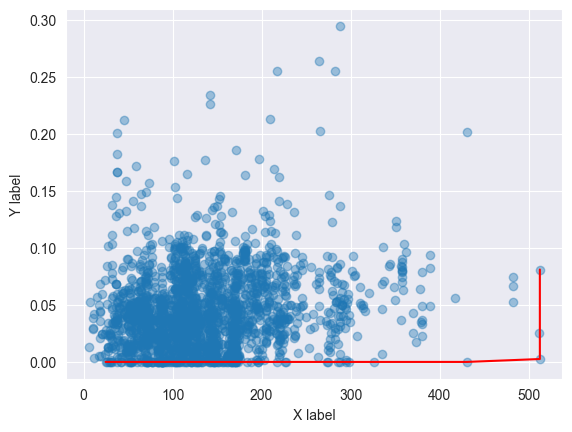

In [18]:
import matplotlib.pyplot as plt

capacity = [doc.capacity_grav for doc in docs if doc.capa is not None]
instabilities = [doc.stability_discharge for doc in docs if doc.stability_charge is not None]

def plot_pareto_frontier(Xs, Ys, maxX=True, maxY=False, xlabel='X label', ylabel='Y label'):
    '''Pareto frontier selection process
    :param Xs: Series of X values
    :param Ys: Series of Y values
    :param maxX: True if maximizing on X
    :param maxY: True if maximizing on Y
    :param xlabel: plot label for X
    :parma ylabel: plot label for Y
    '''
    n = 0
    sorted_list = sorted([[Xs[i], Ys[i]] for i in range(len(Xs))], reverse=maxX) # Sorts values (descending if reverse = True)
    pareto_front = [sorted_list[0]]
    battery_ids = []
    for pair in sorted_list[1:]:
        if maxY:
            if pair[1] >= pareto_front[-1][1]:
                pareto_front.append(pair)
                for id in docs:
                    if id.capacity_grav == pair[0] or id.max_delta_volume == pair[0]:
                        print(f"{id.battery_id}: {pair[0]}V") # Print ID and voltage

        else:
            if pair[1] <= pareto_front[-1][1]:
                pareto_front.append(pair)
                for id in docs:
                    if id.capacity_grav == pair[0] or id.max_delta_volume == pair[0]:
                        print(f"{id.battery_id}: {pair[0]}") # Print ID and voltage


    '''Plotting process'''
    plt.scatter(Xs,Ys, alpha=0.4)
    pf_X = [pair[0] for pair in pareto_front]
    pf_Y = [pair[1] for pair in pareto_front]
    plt.plot(pf_X, pf_Y, color='red')
    plt.xlabel(xlabel)
    plt.ylabel(ylabel)
    plt.show()

    #return pareto_front

plot_pareto_frontier(capacity, instabilities)
